# Classificação com o dataset Olivetti Faces


In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.exceptions import UndefinedMetricWarning

# Ignorando avisos de métricas indefinidas
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

## Carregando e Visualizando o dataset Olivetti Faces


downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


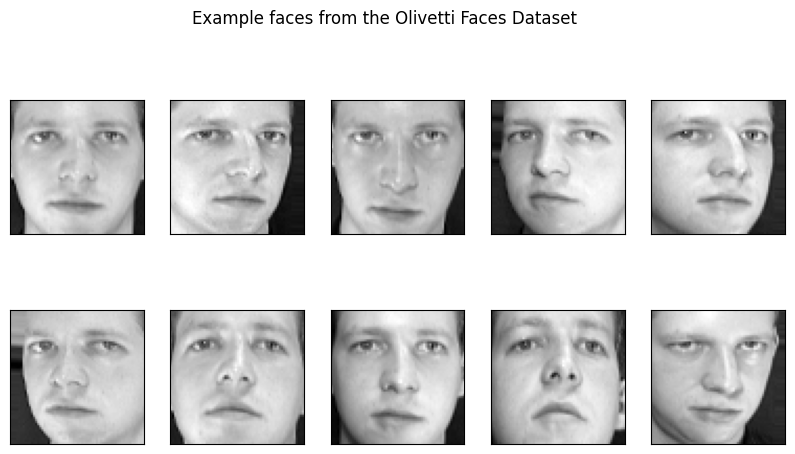

In [2]:
# Carregando o dataset Olivetti Faces
faces = fetch_olivetti_faces()
X, y = faces.data, faces.target

# Visualização de algumas faces do dataset
fig, axes = plt.subplots(2, 5, figsize=(10, 5), subplot_kw={"xticks": [], "yticks": []})
for i, ax in enumerate(axes.flat):
    ax.imshow(faces.images[i], cmap="gray")
plt.suptitle("Example faces from the Olivetti Faces Dataset", y=1.02)
plt.show()

## Dividindo o dataset em treino e teste


In [3]:
# Dividindo o dataset em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

## Treinando e avaliando modelos de classificação


### KNN


In [6]:
# KNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("KNN Classification Report:")
print(classification_report(y_test, y_pred_knn))

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.40      0.36         5
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         2
           3       0.33      0.75      0.46         4
           4       0.50      1.00      0.67         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3
           7       1.00      0.25      0.40         8
           8       0.67      1.00      0.80         2
           9       1.00      1.00      1.00         3
          10       1.00      1.00      1.00         3
          11       0.80      0.80      0.80         5
          12       0.50      0.50      0.50         2
          13       1.00      1.00      1.00         3
          14       0.60      1.00      0.75         3
          15       1.00      0.67      0.80         3
          16       0.00      0.00      0.00         0


### SVM


In [5]:
# SVM
svm = SVC(probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.60      0.55         5
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         2
           3       1.00      0.75      0.86         4
           4       0.50      1.00      0.67         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3
           7       0.00      0.00      0.00         8
           8       0.50      1.00      0.67         2
           9       0.38      1.00      0.55         3
          10       1.00      1.00      1.00         3
          11       1.00      0.80      0.89         5
          12       0.50      1.00      0.67         2
          13       1.00      1.00      1.00         3
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         3
          16       0.00      0.00      0.00         0


### Decision Tree


In [7]:
# Decision Tree
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_tree))

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.67      0.50      0.57         4
           2       0.50      0.50      0.50         2
           3       0.50      0.25      0.33         4
           4       0.33      0.33      0.33         3
           5       1.00      0.67      0.80         3
           6       0.25      0.33      0.29         3
           7       0.75      0.38      0.50         8
           8       0.00      0.00      0.00         2
           9       1.00      1.00      1.00         3
          10       0.20      0.33      0.25         3
          11       0.40      0.40      0.40         5
          12       0.00      0.00      0.00         2
          13       1.00      0.33      0.50         3
          14       0.75      1.00      0.86         3
          15       0.60      1.00      0.75         3
          16       0.00      0.00      0.00 

### Random Forest


In [8]:
# Random Forest
forest = RandomForestClassifier(random_state=42)
forest.fit(X_train, y_train)
y_pred_forest = forest.predict(X_test)
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_forest))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.40      0.57         5
           1       1.00      1.00      1.00         4
           2       0.40      1.00      0.57         2
           3       1.00      1.00      1.00         4
           4       0.67      0.67      0.67         3
           5       0.75      1.00      0.86         3
           6       1.00      1.00      1.00         3
           7       1.00      0.25      0.40         8
           8       0.67      1.00      0.80         2
           9       1.00      1.00      1.00         3
          10       0.60      1.00      0.75         3
          11       1.00      0.80      0.89         5
          12       1.00      1.00      1.00         2
          13       1.00      0.67      0.80         3
          14       1.00      1.00      1.00         3
          15       0.75      1.00      0.86         3
          16       0.00      0.00      0.00 

### Gradient Boosting


In [9]:
# Gradient Boosting Machines com parâmetros ajustados para otimização
gbm = GradientBoostingClassifier(
    n_estimators=50, learning_rate=0.1, max_depth=3, random_state=42
)
gbm.fit(X_train, y_train)
y_pred_gbm = gbm.predict(X_test)
print("Gradient Boosting Machines Classification Report:")
print(classification_report(y_test, y_pred_gbm))

Gradient Boosting Machines Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.20      0.33         5
           1       0.75      0.75      0.75         4
           2       0.40      1.00      0.57         2
           3       0.50      0.25      0.33         4
           4       0.67      0.67      0.67         3
           5       1.00      1.00      1.00         3
           6       0.75      1.00      0.86         3
           7       1.00      0.38      0.55         8
           8       0.00      0.00      0.00         2
           9       0.14      0.33      0.20         3
          10       1.00      0.67      0.80         3
          11       0.67      0.40      0.50         5
          12       0.05      0.50      0.08         2
          13       0.00      0.00      0.00         3
          14       1.00      1.00      1.00         3
          15       1.00      0.33      0.50         3
          16       0.00      0.

## K-Means (para clustering, não classificação)


In [10]:
# Kmeans (para clustering, não classificação)
kmeans = KMeans(n_clusters=40, random_state=42)
kmeans.fit(X)
print("KMeans Cluster Centers Shape:")
print(kmeans.cluster_centers_.shape)

KMeans Cluster Centers Shape:
(40, 4096)


## Validação Cruzada e Pipeline no Sklearn


In [11]:
# Validação Cruzada e Pipeline no Sklearn
pipeline = Pipeline([("scaler", StandardScaler()), ("svc", SVC())])
cross_val_scores = cross_val_score(pipeline, X, y, cv=5)
print("Cross-Validation Scores:", cross_val_scores)

Cross-Validation Scores: [1.     0.9375 0.95   0.9375 0.9125]


## Classification Report e Métricas de Classificação para Random Forest


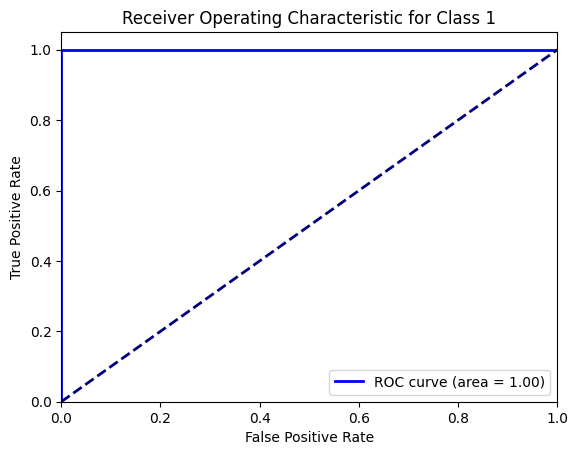

In [12]:
# Classification Report e Métricas de Classificação para Random Forest
y_prob_forest = forest.predict_proba(X_test)

# Calculando a ROC Curve e AUC para cada classe
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(40):
    fpr[i], tpr[i], _ = roc_curve(y_test, y_prob_forest[:, i], pos_label=i)
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve for a specific class
plt.figure()
plt.plot(
    fpr[1], tpr[1], color="blue", lw=2, label="ROC curve (area = %0.2f)" % roc_auc[1]
)
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic for Class 1")
plt.legend(loc="lower right")
plt.show()

## Imprimindo imagens reais vs preditas para todos os modelos


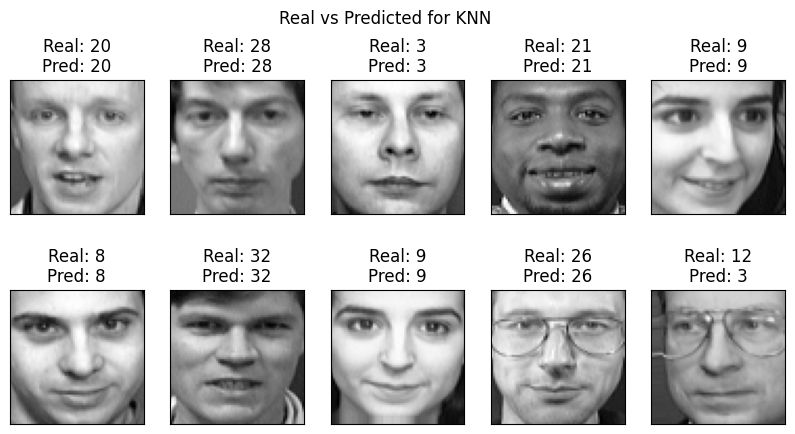

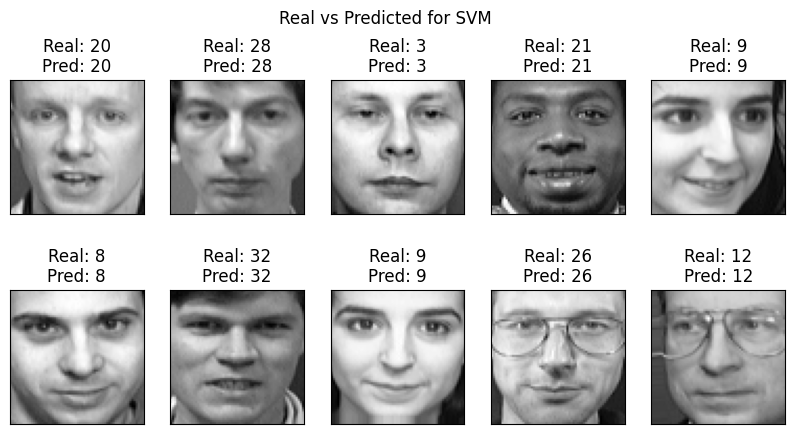

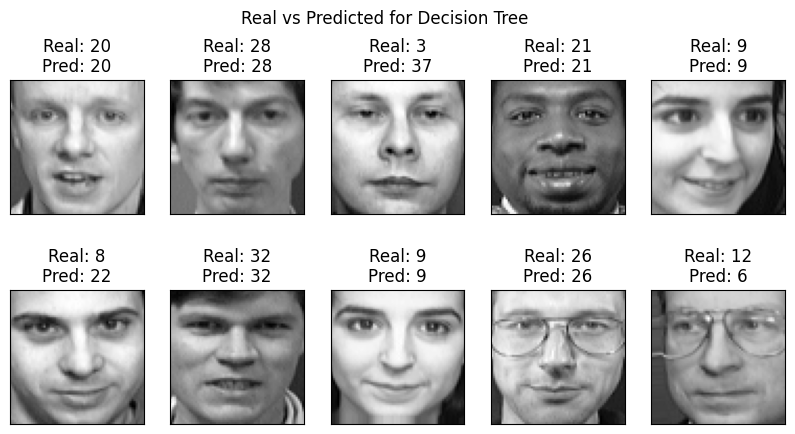

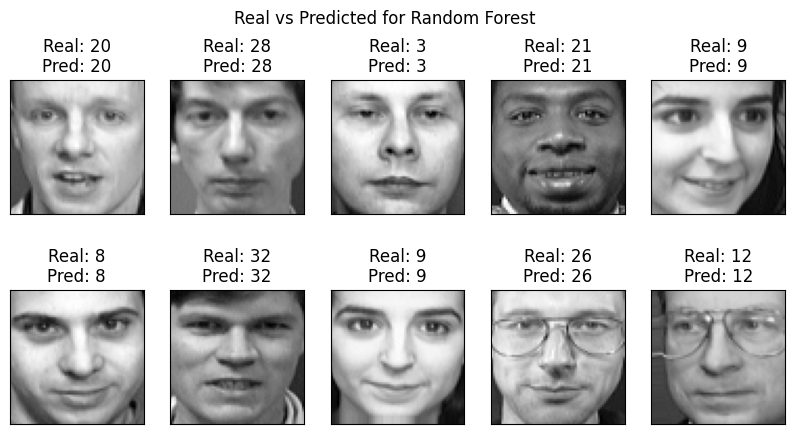

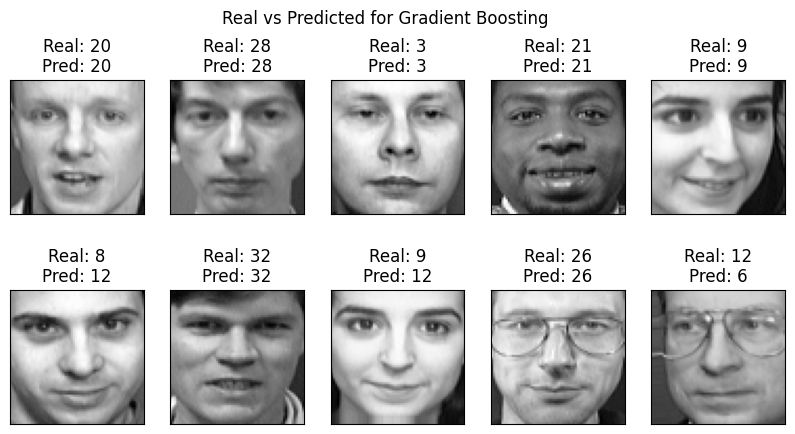

In [13]:
# Definindo modelos novamente para evitar erro NameError
models = {
    "KNN": knn,
    "SVM": svm,
    "Decision Tree": tree,
    "Random Forest": forest,
    "Gradient Boosting": gbm,
}

# Imprimindo imagens reais vs preditas para todos os modelos
for name, model in models.items():
    y_pred = model.predict(X_test)
    fig, axes = plt.subplots(
        2, 5, figsize=(10, 5), subplot_kw={"xticks": [], "yticks": []}
    )
    fig.suptitle(f"Real vs Predicted for {name}")
    for i, ax in enumerate(axes.flat):
        ax.imshow(X_test[i].reshape(64, 64), cmap="gray")
        ax.set_title(f"Real: {y_test[i]}\nPred: {y_pred[i]}")
    plt.show()

## Comparando o desempenho dos modelos


In [14]:
# Comparando o desempenho dos modelos
performance = pd.DataFrame(
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
)

for name, model in models.items():
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    performance.loc[performance.shape[0]] = {
        "Model": name,
        "Accuracy": report["accuracy"],
        "Precision": report["weighted avg"]["precision"],
        "Recall": report["weighted avg"]["recall"],
        "F1-Score": report["weighted avg"]["f1-score"],
    }
performance.set_index("Model", inplace=True)
performance = performance.map(lambda x: f"{100 * x:2.2f} %")
performance.sort_values("F1-Score", ascending=False, inplace=True)


performance

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Random Forest,83.33 %,90.22 %,83.33 %,82.82 %
SVM,80.83 %,85.50 %,80.83 %,79.03 %
KNN,77.50 %,82.26 %,77.50 %,76.28 %
Gradient Boosting,55.00 %,67.81 %,55.00 %,56.92 %
Decision Tree,53.33 %,62.49 %,53.33 %,53.81 %
